In [1]:
from dataclasses import replace

import imageio.v2 as imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import moto.src.bc as _bc
import moto.src.geometry as _geom
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
import moto.src.viz as _viz
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField
from moto.src.material import StructuralMaterial
from moto.src.nl_solver import LinearSolvers
from moto.src.solve import newton_solve

_Field = StructField


GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []
jax.config.update("jax_enable_x64", True)


/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


<Axes: xlabel='X', ylabel='Y'>

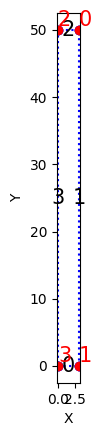

In [3]:
geom = _geom.BrepGeometry(brep_file="../brep/bar.json")

mesh = _mesher.grid_mesh_brep(
  brep=geom,
  nelx_desired=1,
  nely_desired=16,
  dofs_per_node=2,
  gauss_order=2,
)
_viz.plot_brep(geom)

<Axes: title={'center': 'Boundary Conditions'}>

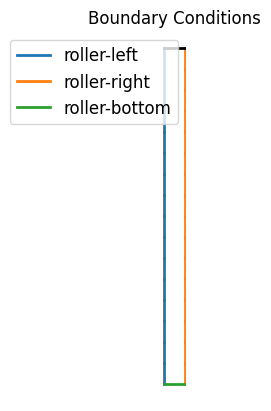

In [4]:
face_tol = float(np.asarray(mesh.elem_size)[0]) * 0.5

BOTTOM, RIGHT, TOP, LEFT = 0, 1, 2, 3

left_faces = _bc.identify_faces(mesh, edges=[geom.edges[LEFT]], tol=face_tol)
right_faces = _bc.identify_faces(mesh, edges=[geom.edges[RIGHT]], tol=face_tol)
bottom_faces = _bc.identify_faces(mesh, edges=[geom.edges[BOTTOM]], tol=face_tol)

# Left: U=0
nL = len(left_faces)
left_bc = _bc.DirichletBC(
  elem_faces=left_faces, values=[(_Field.U, np.zeros(nL))], name="roller-left"
)

# Right: U=0
nR = len(right_faces)
right_bc = _bc.DirichletBC(
  elem_faces=right_faces, values=[(_Field.U, np.zeros(nR))], name="roller-right"
)

# Bottom: V=0
nB = len(bottom_faces)
bottom_bc = _bc.DirichletBC(
  elem_faces=bottom_faces, values=[(_Field.V, np.zeros(nB))], name="roller-bottom"
)

bc_list = [left_bc, right_bc, bottom_bc]  # no top load
bc = _bc.process_boundary_conditions(bc_list, mesh)


# visualize
_viz.plot_bc(bc_list, mesh)

In [5]:
mat = StructuralMaterial(youngs_modulus=1e4, poissons_ratio=0.0, mass_density=80.0)

# ---- MPs ----
occupied_element_ids = np.arange(mesh.num_elems, dtype=int)
num_mp_per_elem_per_dim = 2

mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)

num_mat_pts = mp_coords.shape[0]
dom_len = np.asarray(mesh.elem_size) / (2 * num_mp_per_elem_per_dim)
vp = (2**mesh.num_dim) * float(np.prod(dom_len))

max_nodes_per_point = int(3**mesh.num_dim)
max_elems_per_point = int(2**mesh.num_dim)

mp_state, mp_grid_map0 = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes_per_point,
  max_elems_per_point=max_elems_per_point,
)

dom_len_j = jnp.asarray(dom_len)
mp_coords_j = jnp.asarray(mp_coords)

vp_j = jnp.asarray(vp)
mass_j = vp_j * jnp.asarray(mat.mass_density)

mp_state = replace(
  mp_state,
  coord=mp_coords_j,
  volume=vp_j * jnp.ones((num_mat_pts,), dtype=mp_coords_j.dtype),
  volume0=vp_j * jnp.ones((num_mat_pts,), dtype=mp_coords_j.dtype),
  mass=mass_j * jnp.ones((num_mat_pts,), dtype=mp_coords_j.dtype),
  domain_length=jnp.tile(dom_len_j[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(dom_len_j[None, :], (num_mat_pts, 1)),
)


In [6]:
tol, NRitMax = 1e-9, 10
nDoF = mesh.num_dofs
uvw = np.zeros((nDoF, 1), dtype=float)

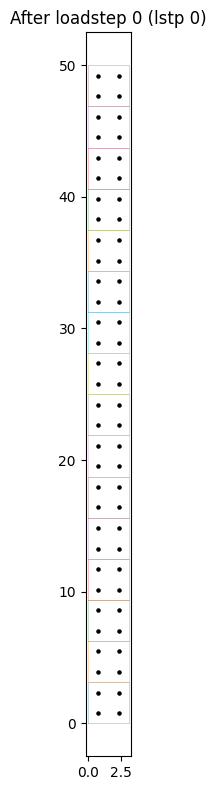

In [7]:
_frame_hw = None


def post_pro(mesh, mp_state, uvw, lstp, title="", record=False, gif=None):
  """Quick scatter of MPs + background grid; can collect frames for a GIF."""
  global _frame_hw

  coord = np.asarray(mesh.nodes.coords)
  etpl = np.asarray(mesh.elem_nodes)

  fig, ax = plt.subplots(figsize=(4, 8))

  # draw grid
  for e in range(etpl.shape[0]):
    xy = coord[etpl[e], :]
    xy = np.vstack([xy, xy[0]])
    ax.plot(xy[:, 0], xy[:, 1], lw=0.5, alpha=0.4)

  # plot MPs (dataclass or legacy dict both work)
  mp_coord = mp_state.coord if hasattr(mp_state, "coord") else mp_state["coord"]
  mp_xy = np.asarray(mp_coord)
  ax.scatter(mp_xy[:, 0], mp_xy[:, 1], s=5, c="k")

  ax.set_title(f"{title} (lstp {lstp})")
  ax.set_aspect("equal")
  plt.tight_layout()

  if record and isinstance(gif, list):
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[..., :3]

    if _frame_hw is None:
      _frame_hw = frame.shape[:2]
    elif frame.shape[:2] != _frame_hw:
      frame = np.asarray(
        Image.fromarray(frame, mode="RGB").resize(
          (_frame_hw[1], _frame_hw[0]), Image.BILINEAR
        )
      )

    gif.append(frame.copy())

  plt.show()
  plt.close(fig)


# initial frame
post_pro(mesh, mp_state, uvw, lstp=0, title="After loadstep 0", record=True)


def _post(mesh, mp_state, uvw, lstp):
  post_pro(
    mesh, mp_state, uvw, lstp, title=f"After loadstep {lstp}", record=True, gif=frames
  )


step 1/40
NR converged in 4 iters, res_norm/res_norm_0: 4.1171177121639973e-13


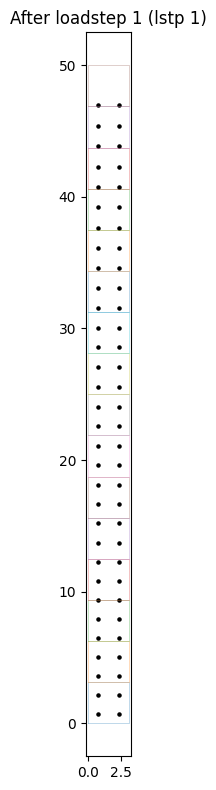

step 2/40
NR converged in 4 iters, res_norm/res_norm_0: 1.8917043258421854e-14


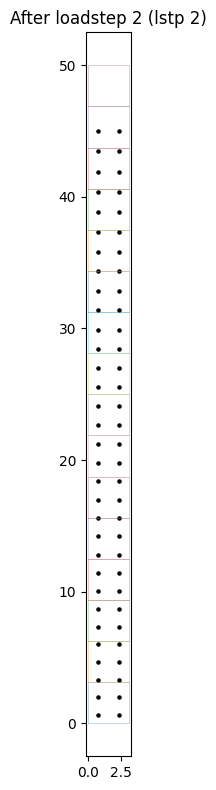

step 3/40
NR converged in 4 iters, res_norm/res_norm_0: 1.3953031799624816e-14


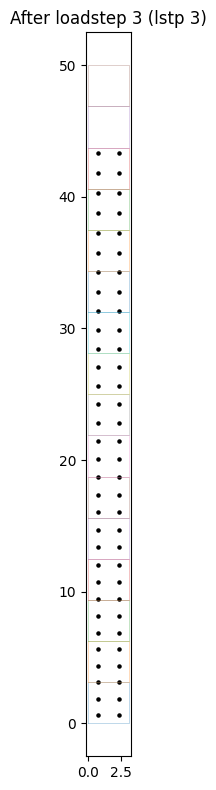

step 4/40
NR converged in 4 iters, res_norm/res_norm_0: 1.347786551373916e-14


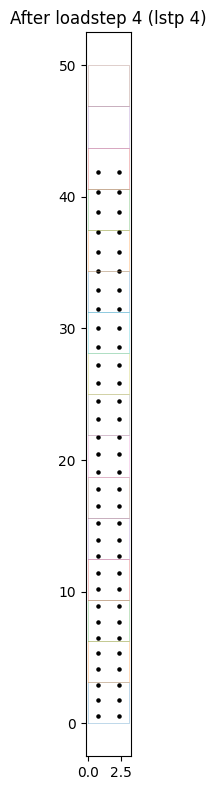

step 5/40
NR converged in 4 iters, res_norm/res_norm_0: 1.1302905376753e-14


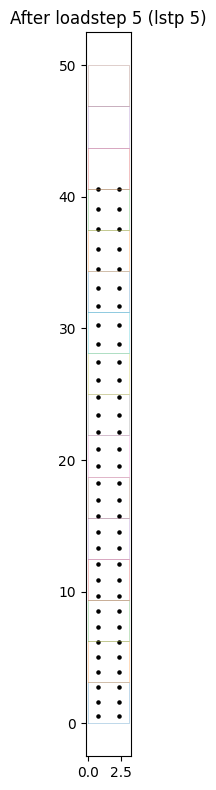

step 6/40
NR converged in 4 iters, res_norm/res_norm_0: 1.019281141246475e-14


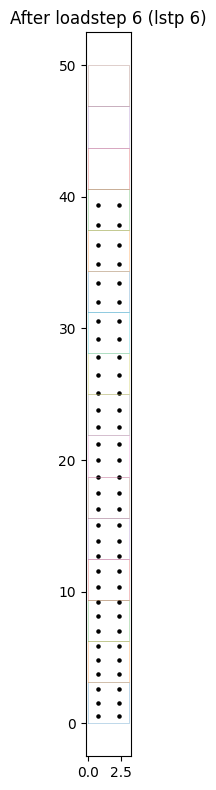

step 7/40
NR converged in 4 iters, res_norm/res_norm_0: 1.6727994784198917e-14


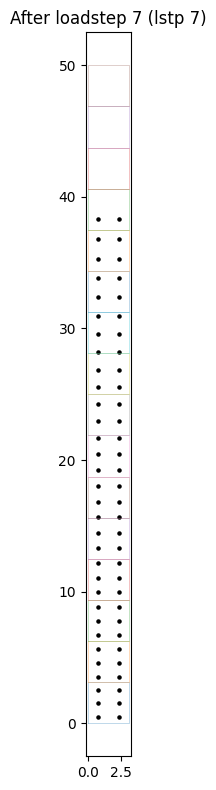

step 8/40
NR converged in 4 iters, res_norm/res_norm_0: 1.3733172025118398e-14


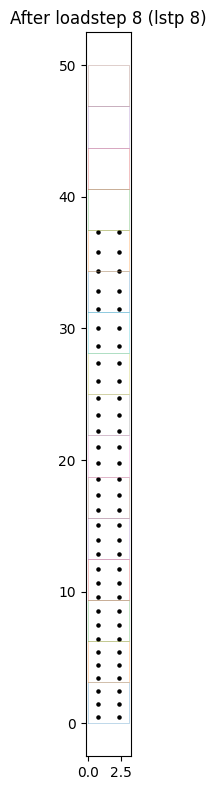

step 9/40
NR converged in 4 iters, res_norm/res_norm_0: 1.3115926274766971e-14


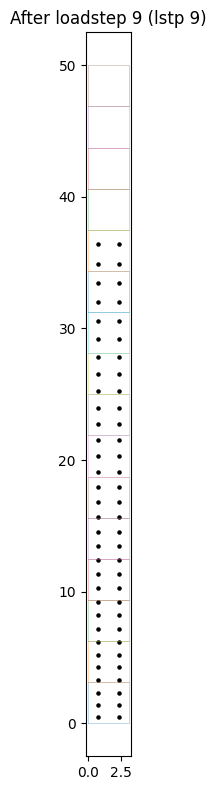

step 10/40
NR converged in 4 iters, res_norm/res_norm_0: 1.535091514198082e-14


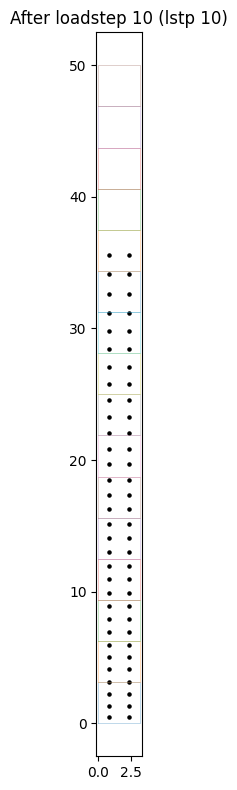

step 11/40
NR converged in 3 iters, res_norm/res_norm_0: 7.823808647500916e-10


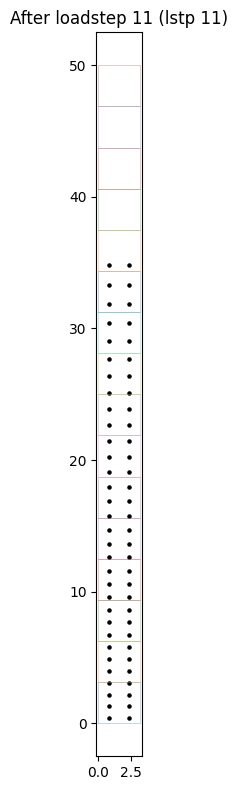

step 12/40
NR converged in 3 iters, res_norm/res_norm_0: 5.069139069415543e-10


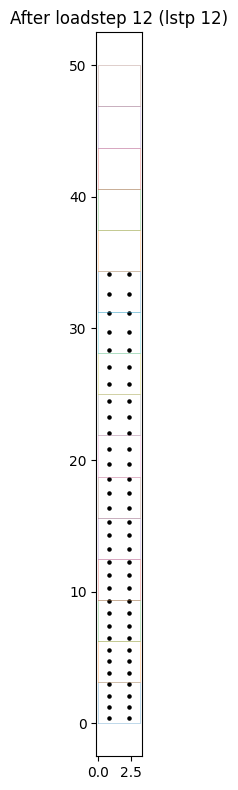

step 13/40
NR converged in 3 iters, res_norm/res_norm_0: 3.185733636895656e-10


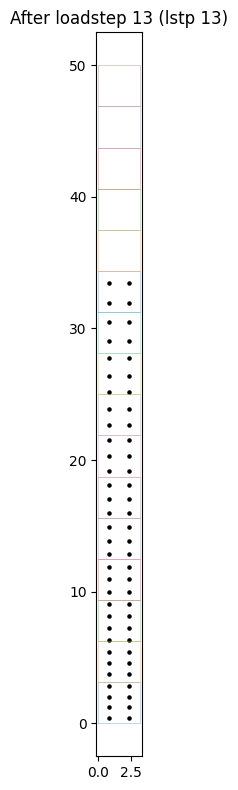

step 14/40
NR converged in 3 iters, res_norm/res_norm_0: 2.1534815417101304e-10


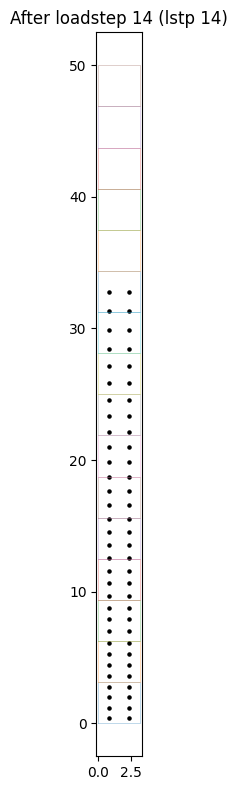

step 15/40
NR converged in 3 iters, res_norm/res_norm_0: 1.3970686578013466e-10


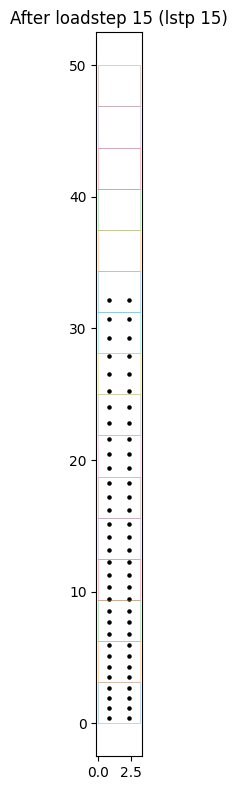

step 16/40
NR converged in 3 iters, res_norm/res_norm_0: 1.037386407466343e-10


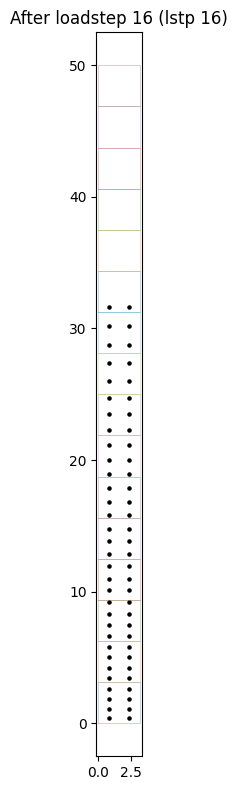

step 17/40
NR converged in 3 iters, res_norm/res_norm_0: 8.777452265989843e-11


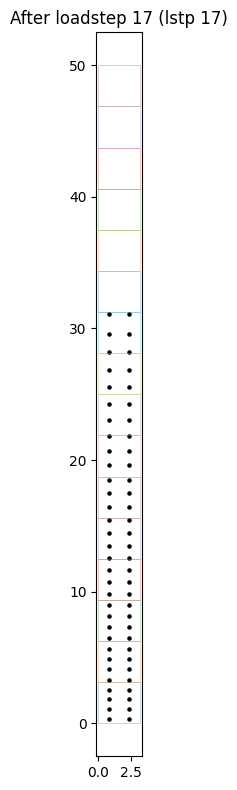

step 18/40
NR converged in 3 iters, res_norm/res_norm_0: 6.076967331969511e-11


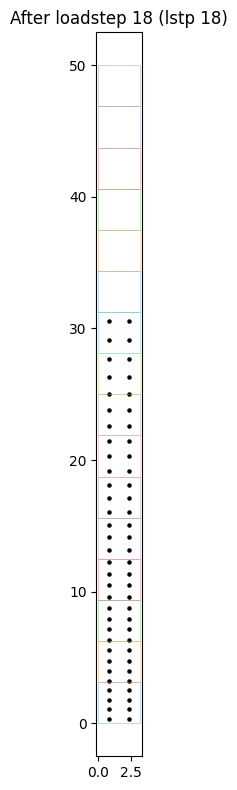

step 19/40
NR converged in 3 iters, res_norm/res_norm_0: 4.357520247020571e-11


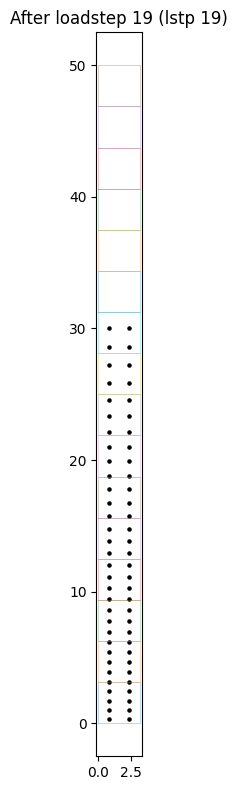

step 20/40
NR converged in 3 iters, res_norm/res_norm_0: 3.2891060977950493e-11


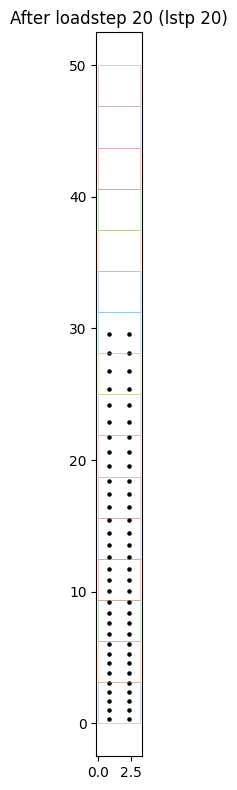

step 21/40
NR converged in 3 iters, res_norm/res_norm_0: 2.429708500642504e-11


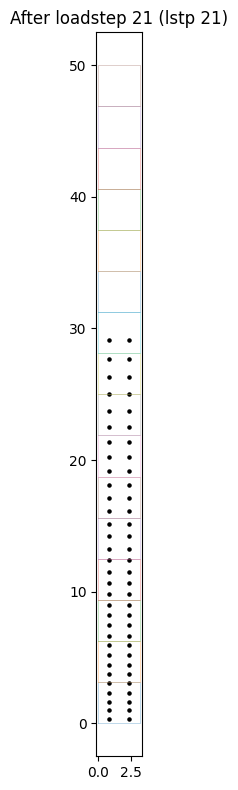

step 22/40
NR converged in 3 iters, res_norm/res_norm_0: 1.6215059875186602e-11


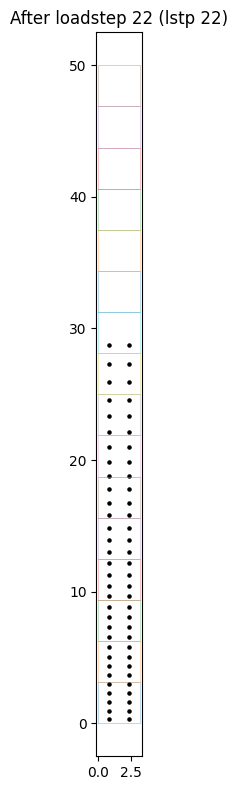

step 23/40
NR converged in 3 iters, res_norm/res_norm_0: 1.3903459752355402e-11


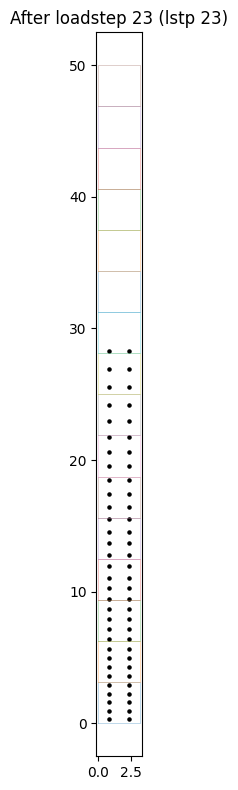

step 24/40
NR converged in 3 iters, res_norm/res_norm_0: 1.0393879476989933e-11


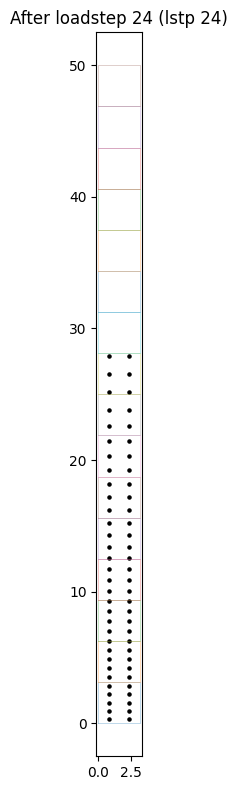

step 25/40
NR converged in 3 iters, res_norm/res_norm_0: 7.769864693226798e-12


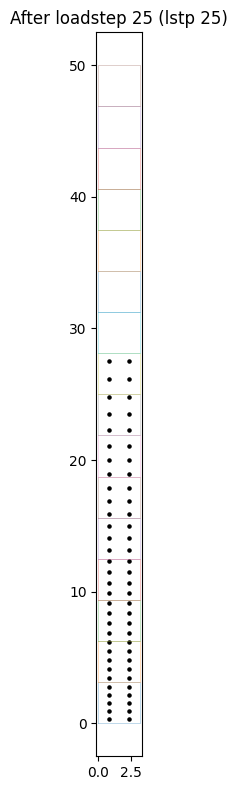

step 26/40
NR converged in 3 iters, res_norm/res_norm_0: 6.8382734755491075e-12


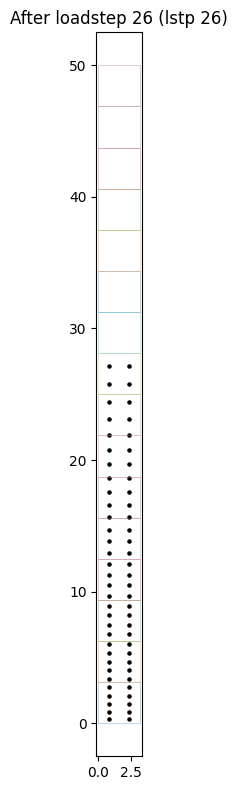

step 27/40
NR converged in 3 iters, res_norm/res_norm_0: 6.444660783712304e-12


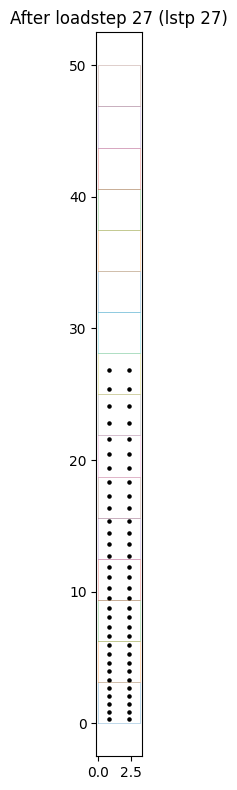

step 28/40
NR converged in 3 iters, res_norm/res_norm_0: 5.515476731624163e-12


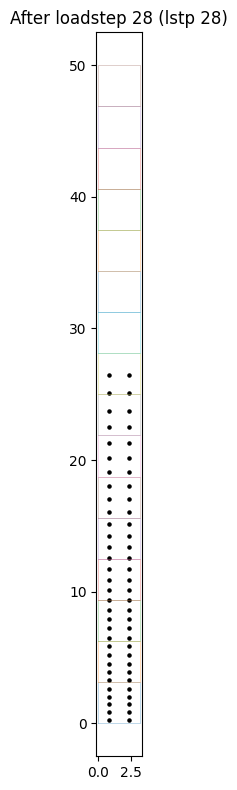

step 29/40
NR converged in 3 iters, res_norm/res_norm_0: 3.4938465378297124e-12


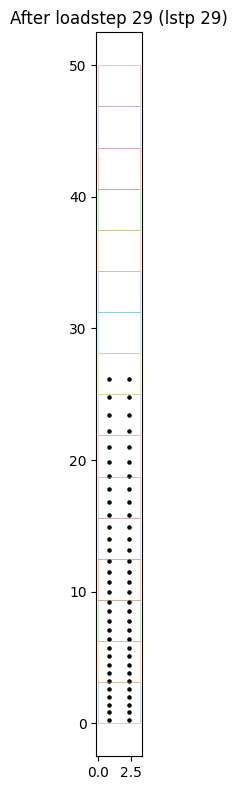

step 30/40
NR converged in 3 iters, res_norm/res_norm_0: 2.965397131985919e-12


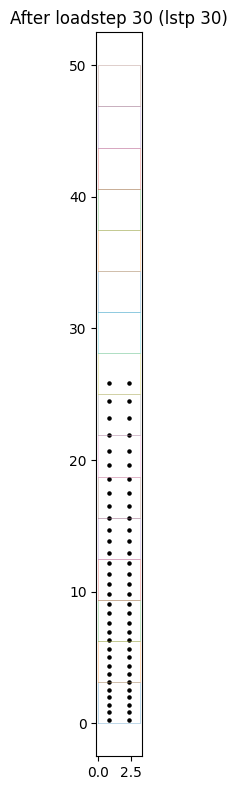

step 31/40
NR converged in 3 iters, res_norm/res_norm_0: 2.3594123231006577e-12


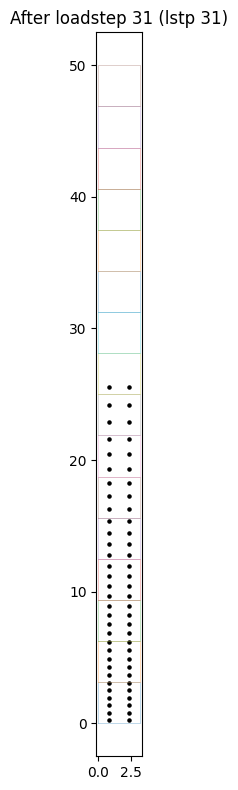

step 32/40
NR converged in 3 iters, res_norm/res_norm_0: 1.982385495773974e-12


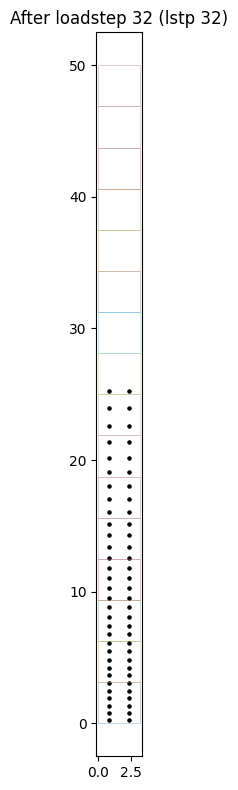

step 33/40
NR converged in 3 iters, res_norm/res_norm_0: 1.5110935375664632e-12


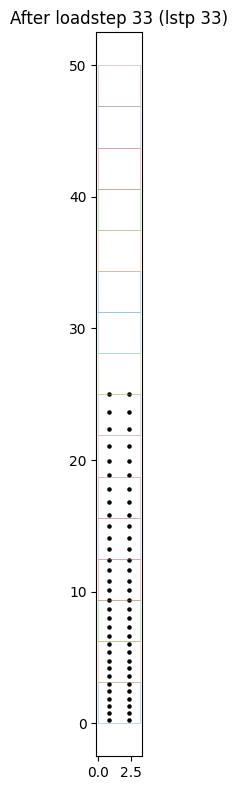

step 34/40
NR converged in 3 iters, res_norm/res_norm_0: 1.3719072748242389e-12


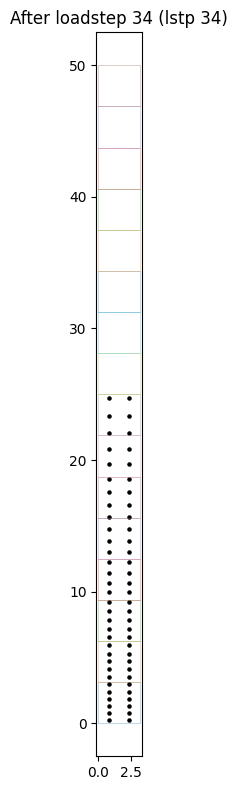

step 35/40
NR converged in 3 iters, res_norm/res_norm_0: 1.0962482408872488e-12


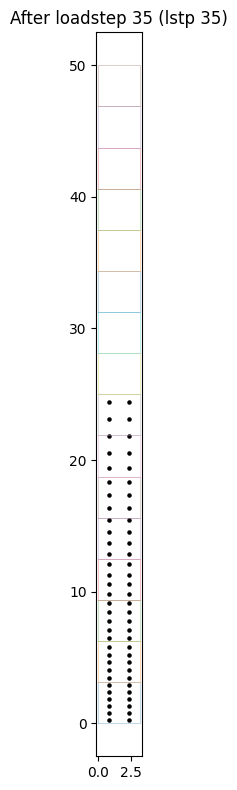

step 36/40
NR converged in 3 iters, res_norm/res_norm_0: 1.0373462132489374e-12


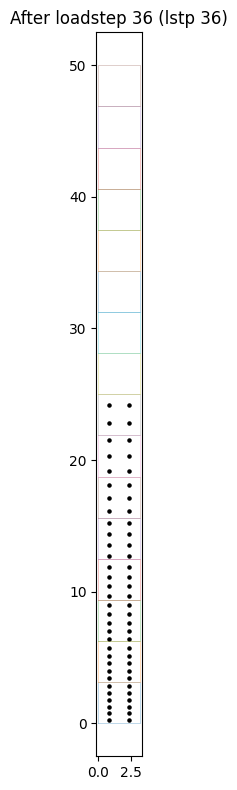

step 37/40
NR converged in 3 iters, res_norm/res_norm_0: 8.539239569180245e-13


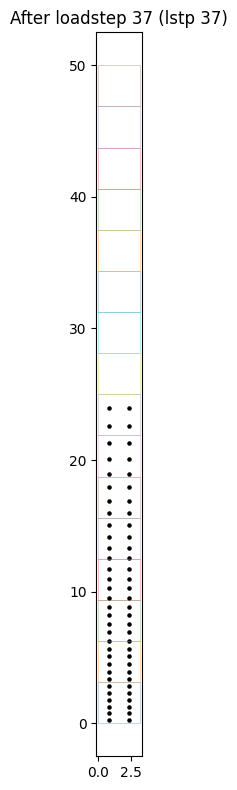

step 38/40
NR converged in 3 iters, res_norm/res_norm_0: 7.18765289887956e-13


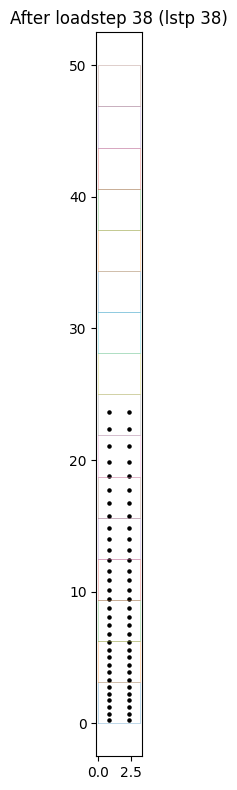

step 39/40
NR converged in 3 iters, res_norm/res_norm_0: 6.987593866172777e-13


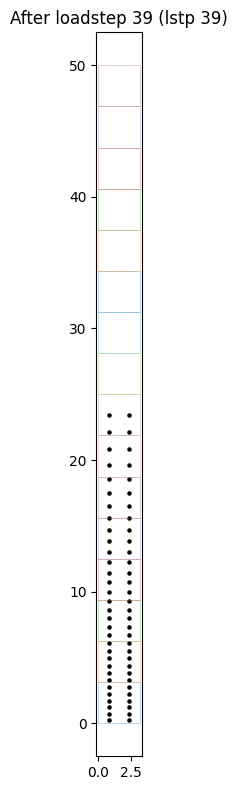

step 40/40
NR converged in 3 iters, res_norm/res_norm_0: 5.778615179127436e-13


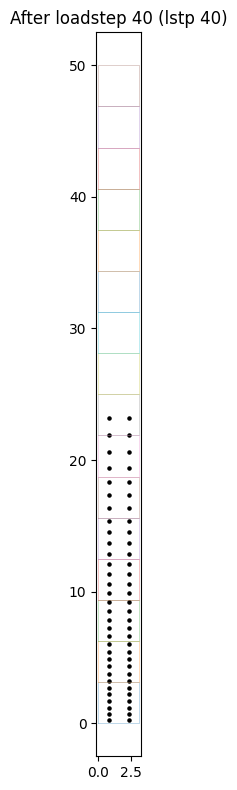

In [8]:
load_stps, g, tol, max_nr_iter = 40, 10.0, 1e-9, 10

solver_settings = {
  "linear": {"solver": LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,))
gravity_vec = jnp.zeros((mesh.num_dim,)).at[-1].set(-abs(float(g)))

lam = mat.lame_parameters[0] * jnp.ones((num_mat_pts,))
mu = mat.lame_parameters[1] * jnp.ones((num_mat_pts,))
matpt_config, uvw = newton_solve(
  mesh=mesh,
  mp_state=mp_state,
  bc=bc,
  du_guess=du_guess,
  load_steps=load_stps,
  gravity=gravity_vec,
  mpm_problem=mpm_problem,
  lame_lambda=lam,
  lame_mu=mu,
  post_cb=_post,
)


In [9]:
imageio.mimsave("mpm.gif", frames, duration=0.3, loop=0)